In [4]:
import dotenv
import os
import pandas as pd
import irw
import polars as pl
import pairadigm as pdm
dotenv.load_dotenv()

True

In [14]:
# Pull all IRW tables that have item text available, age range is <=18, construct is cognitive/educational, measurement tool is test, item format is Likert/constructed response, and language is English
irw_edtexts = irw.fetch([
    'gilbert_meta_23',
    'gilbert_meta_102',
    'gilbert_meta_103',
    'gilbert_meta_104',
    'gilbert_meta_26',
    'gilbert_meta_2',
    'preschool_sel_akt',
    'frac20'
])

ERROR:irw.operations.fetch:Error fetching dataset 'eng' : Not found: datapages.item_response_warehouse_2:epbx:v7_0.eng


## Testing with gilbert_meta_23

In [45]:
df = irw_edtexts['gilbert_meta_103']
gilbert_for_testing = pl.DataFrame(df)
print(gilbert_for_testing.shape)
gilbert_for_testing.head()

(53466, 21)


id,item,resp,item_num,item_cov_transfer,rt,ln_rt,s_rt,i_rt,cluster_id,block_id,treat,cov_black,cov_male,cov_lep,cov_homelang_english,cov_iep,cov_ses_high,cov_ses_med,cov_ses_low,std_baseline
i64,str,i64,i64,str,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str
1545,"""cc_q18""",0,18,"""Mid""","""0.7740000262856483""","""-0.25618337143162456""",0.996693,2.344194,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q9""",0,9,"""Near""","""1.574000045657158""","""0.45362017900229995""",0.996693,2.65125,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q2""",0,2,"""Near""","""13.985000252723694""","""2.637985344724977""",0.996693,4.290656,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q31""",0,31,"""Far""","""0.9020000137388706""","""-0.10314074368794963""",0.996693,1.910889,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""
1545,"""cc_q4""",0,4,"""Near""","""1.2719999626278877""","""0.24059043553733855""",0.996693,3.080331,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272"""


In [46]:
gilbert_for_testing.select(pl.col('item').value_counts())

item
struct[2]
"{""cc_q14"",1862}"
"{""cc_q28"",1789}"
"{""cc_q4"",1905}"
"{""cc_q22"",1824}"
"{""cc_q8"",1896}"
…
"{""cc_q30"",1785}"
"{""cc_q34"",1779}"
"{""cc_q33"",1777}"


In [51]:
text = irw.itemtext("gilbert_meta_103")
text = pl.DataFrame(text)
print(text.shape)
text.head()

(174, 10)


table,section_id,item,instrument,instructions,section_prompt,item_text,option_text,resp_raw,resp
str,str,str,str,str,str,str,str,str,str
"""gilbert_meta_103""","""monkeys""","""cc_q10""","""reading comprehension""","""NA""","""1) A human is a primate. In pr…","""9. How did scientists know tha…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""monkeys""","""cc_q11""","""reading comprehension""","""NA""","""1) A human is a primate. In pr…","""10. What is this passage mostl…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""birds""","""cc_q14""","""reading comprehension""","""NA""","""1) Some birds that are here to…","""1. What is the main question t…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""birds""","""cc_q15""","""reading comprehension""","""NA""","""1) Some birds that are here to…","""2. Which sentence best summari…","""NA""","""NA""","""0"""
"""gilbert_meta_103""","""birds""","""cc_q16""","""reading comprehension""","""NA""","""1) Some birds that are here to…","""3. Scientists found that when …","""NA""","""NA""","""0"""


In [61]:
text_agg = text.group_by("item").agg(
    pl.col("section_prompt").first(),
    pl.col("item_text").first(),
    pl.col("option_text").filter(pl.col("option_text") != "NA").str.join("\n").alias("options")
).with_columns(
    (pl.col("section_prompt") + ": " + 
     pl.col("item_text") + "\n" +
     pl.col("options"))
    .alias("combined_text")
).drop("options")

text_agg.write_csv("../data/processed/gilbert_meta_103_full-itemtext.csv")
print(text_agg.shape)
text_agg.head()

(29, 4)


item,section_prompt,item_text,combined_text
str,str,str,str
"""cc_q15""","""1) Some birds that are here to…","""2. Which sentence best summari…","""1) Some birds that are here to…"
"""cc_q6""","""1) A human is a primate. In pr…","""5. What is the purpose of this…","""1) A human is a primate. In pr…"
"""cc_q5""","""1) A human is a primate. In pr…","""4. Why do scientists study mon…","""1) A human is a primate. In pr…"
"""cc_q20""","""1) Some birds that are here to…","""7. The author of this article …","""1) Some birds that are here to…"
"""cc_q30""","""1) In many ways, skyscrapers a…","""5. According to paragraph 4, a…","""1) In many ways, skyscrapers a…"


In [63]:
gilbert_for_testing_merge = gilbert_for_testing.join(
    text_agg, 
    on=["item"], 
    how="left"
)
print(gilbert_for_testing_merge.shape)
gilbert_for_testing_merge.head()

(53466, 24)


id,item,resp,item_num,item_cov_transfer,rt,ln_rt,s_rt,i_rt,cluster_id,block_id,treat,cov_black,cov_male,cov_lep,cov_homelang_english,cov_iep,cov_ses_high,cov_ses_med,cov_ses_low,std_baseline,section_prompt,item_text,combined_text
i64,str,i64,i64,str,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str
1545,"""cc_q18""",0,18,"""Mid""","""0.7740000262856483""","""-0.25618337143162456""",0.996693,2.344194,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) Some birds that are here to…","""5. What is the main idea of th…","""1) Some birds that are here to…"
1545,"""cc_q9""",0,9,"""Near""","""1.574000045657158""","""0.45362017900229995""",0.996693,2.65125,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""8. Structure means""","""1) A human is a primate. In pr…"
1545,"""cc_q2""",0,2,"""Near""","""13.985000252723694""","""2.637985344724977""",0.996693,4.290656,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""1. According to the passage, w…","""1) A human is a primate. In pr…"
1545,"""cc_q31""",0,31,"""Far""","""0.9020000137388706""","""-0.10314074368794963""",0.996693,1.910889,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) In many ways, skyscrapers a…","""6. To send a signal can also m…","""1) In many ways, skyscrapers a…"
1545,"""cc_q4""",0,4,"""Near""","""1.2719999626278877""","""0.24059043553733855""",0.996693,3.080331,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""3. What medical mystery are sc…","""1) A human is a primate. In pr…"


### pairadigm

In [66]:
cgcot_prompts = [
    "Summarize the core task, question, or scenario presented in this item. Item text: {text}",
    "Identify the primary knowledge domain, skill, or psychological construct this item is attempting to measure and give a concise justification. Text: {text}",
    "Analyze the complexity of this item. Does solving or endorsing it require single-step recall, multi-step reasoning, synthesis of disparate information, or the application of abstract rules? CONCISELY identify any structural elements—such as dense vocabulary, tricky distractors, conditional logic, or complex phrasing—that increase the cognitive load required to answer it. Text: {text}",
    "Using only your previous answers, describe the overall latent 'ability' or level of the target construct required for a respondent to successfully answer or endorse this item. Previous answers: {text}"
]

In [64]:
text_agg_pd = text_agg.to_pandas()
text_agg_pd['combined_text'] = text_agg_pd['combined_text'].astype(str)
text_agg_pd.head()

,item,section_prompt,item_text,combined_text
0,cc_q15,1) Some birds that are here today are smaller ...,2. Which sentence best summarizes paragraph 2?,1) Some birds that are here today are smaller ...
1,cc_q6,"1) A human is a primate. In primates, the hear...",5. What is the purpose of this passage?,"1) A human is a primate. In primates, the hear..."
2,cc_q5,"1) A human is a primate. In primates, the hear...",4. Why do scientists study monkey hearts?,"1) A human is a primate. In primates, the hear..."
3,cc_q20,1) Some birds that are here today are smaller ...,7. The author of this article mainly wants you...,1) Some birds that are here today are smaller ...
4,cc_q30,"1) In many ways, skyscrapers are like the huma...","5. According to paragraph 4, a skyscraper’s co...","1) In many ways, skyscrapers are like the huma..."


In [67]:
p = pdm.Pairadigm(
    data=text_agg_pd, 
    item_id_name='item',
    text_name='combined_text',
    cgcot_prompts=cgcot_prompts, 
    model_name="gemini-3.1-flash-lite-preview",
    api_key=os.getenv("GEMINI_API_KEY"),
    target_concept='higher underlying level of the targeted latent trait or ability', 
    save_dir="../results/gilbert_meta_103_test_run"
)

In [68]:
p.test_clients_connection()

Testing LLM client connections using: 'What is the best restaurant in Detroit, MI?'...
  gemini-3.1-flash-lite-preview: MODEL OK


{'gemini-3.1-flash-lite-preview': True}

In [70]:
p.estimate_costs(
    custom_cost_per_1m_input=0.25, 
    custom_cost_per_1m_output=1.50
)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite-preview
Pricing used: $0.250 per 1M input | $1.500 per 1M output
  [Breakdowns] Items: 29, Expected Input: ~63,789, Expected Output: ~23,200
  >>> Estimated Cost: $0.0507
------------------------------------------------------------


In [71]:
p.generate_breakdowns(max_workers=32)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite-preview
Pricing used: Unknown or $0 per 1M tokens
  [Breakdowns] Items: 29, Expected Input: ~63,789, Expected Output: ~23,200
  >>> Estimated Cost: $0.0000
------------------------------------------------------------

Generating breakdowns for 29 items using: gemini-3.1-flash-lite-preview


[gemini-3.1-flash-lite-preview]: 100%|██████████| 29/29 [00:04<00:00,  7.01it/s]

Completed: 29/29 items

Breakdowns added to [object].data — column(s): CGCoT_Breakdown
Pairadigm saved to: ../results/gilbert_meta_103_test_run/
  Files written: metadata.json, data.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/gilbert_meta_103_test_run


In [73]:
p.generate_pairings(num_pairs_per_item=15, breakdowns=True)

Pairwise DataFrame created and stored in self.pairwise_df


,item1,item2,breakdown1,breakdown2
0,cc_q10,cc_q14,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...
1,cc_q18,cc_q9,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...
2,cc_q19,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar..."
3,cc_q16,cc_q18,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...
4,cc_q8,cc_q22,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...
...,...,...,...,...
243,cc_q34,cc_q4,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...
244,cc_q31,cc_q16,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) Some birds that are here tod...
245,cc_q17,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar..."
246,cc_q28,cc_q9,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...


In [74]:
ex = p.pairwise_df['breakdown1'][0]

# textwrap ex
import textwrap
print(textwrap.fill(ex, width=80))

Original Text: 1) A human is a primate. In primates, the heart sends oxygen in
the blood all around the body. The body must have oxygen to function properly.
The strong heart muscle contracts to pump blood all around the body. A healthy
heart never rests.2) But what happens when a person’s heart gets weaker? People
with weak hearts need help. Scientists have to study a medical mystery. Then
they might be able to help people. 3) First, scientists need to diagnose the
reasons that a human heart gets weak. They need to do tests. But sometimes it
would be hard on a sick person to have tests done. So, scientists study animals
that have body systems like humans. Scientists knew that the macaque monkey’s
heart is similar to the human heart. So, they did tests with macaque monkeys.
The scientists learned what happens when a monkey has a heart attack. After a
heart attack, the monkey’s heart muscle has scar tissue where it was damaged.
The scar tissue cannot contract like a strong heart muscle 

In [76]:
p.generate_pairwise_annotations(max_workers=32)


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gemini-3.1-flash-lite-preview
Pricing used: Unknown or $0 per 1M tokens
  [Pairwise] Pairs: 248, Expected Input: ~386,880, Expected Output: ~12,400
  >>> Estimated Cost: $0.0000
------------------------------------------------------------


[default] Pairwise comparisons: 100%|██████████| 248/248 [00:07<00:00, 33.51it/s]

Pairadigm saved to: ../results/gilbert_meta_103_test_run/
  Files written: metadata.json, data.parquet, pairwise_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/gilbert_meta_103_test_run


,item1,item2,breakdown1,breakdown2,decision,justification
0,cc_q10,cc_q14,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
1,cc_q18,cc_q9,Original Text: 1) Some birds that are here tod...,Original Text: 1) A human is a primate. In pri...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
2,cc_q19,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
3,cc_q16,cc_q18,Original Text: 1) Some birds that are here tod...,Original Text: 1) Some birds that are here tod...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
4,cc_q8,cc_q22,Original Text: 1) A human is a primate. In pri...,Original Text: 1) Some birds that are here tod...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
...,...,...,...,...,...,...
243,cc_q34,cc_q4,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,Text2,FINAL ANSWER: <Description 2>\n\nJUSTIFICATION...
244,cc_q31,cc_q16,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) Some birds that are here tod...,Text2,FINAL ANSWER: <Description 2>\n\nJUSTIFICATION...
245,cc_q17,cc_q28,Original Text: 1) Some birds that are here tod...,"Original Text: 1) In many ways, skyscrapers ar...",Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...
246,cc_q28,cc_q9,"Original Text: 1) In many ways, skyscrapers ar...",Original Text: 1) A human is a primate. In pri...,Text1,FINAL ANSWER: <Description 1>\n\nJUSTIFICATION...


In [77]:
p.pairwise_df['decision'].value_counts()

decision
Text1    177
Text2     71
Name: count, dtype: int64

In [80]:
p.score_items(normalization_scale=(-3, 3));
p.scored_df.head()

[default] Fitting Bradley-Terry model...
[default] Mean higher underlying level of the targeted latent trait or ability score: 0.679
[default] Std  higher underlying level of the targeted latent trait or ability score: 1.834

Summary statistics (Bradley_Terry_Score):
  mean: 0.679
  median: 1.149
  std: 1.834
  min: -3.000
  max: 3.000
  count: 29.000
Pairadigm saved to: ../results/gilbert_meta_103_test_run/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: ../results/gilbert_meta_103_test_run


,item,section_prompt,item_text,combined_text,CGCoT_Breakdown,Bradley_Terry_Score,Bradley_Terry_SE
0,cc_q15,1) Some birds that are here today are smaller ...,2. Which sentence best summarizes paragraph 2?,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,2.616933,2.835286
1,cc_q6,"1) A human is a primate. In primates, the hear...",5. What is the purpose of this passage?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,3.000000,3.658073
2,cc_q5,"1) A human is a primate. In primates, the hear...",4. Why do scientists study monkey hearts?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,2.618206,2.480030
3,cc_q20,1) Some birds that are here today are smaller ...,7. The author of this article mainly wants you...,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,2.945090,3.587804
4,cc_q30,"1) In many ways, skyscrapers are like the huma...","5. According to paragraph 4, a skyscraper’s co...","1) In many ways, skyscrapers are like the huma...","Original Text: 1) In many ways, skyscrapers ar...",2.425426,2.716604


In [82]:
p.plot_score_distribution()

### IRT

In [86]:
gilbert_for_testing_merge

id,item,resp,item_num,item_cov_transfer,rt,ln_rt,s_rt,i_rt,cluster_id,block_id,treat,cov_black,cov_male,cov_lep,cov_homelang_english,cov_iep,cov_ses_high,cov_ses_med,cov_ses_low,std_baseline,section_prompt,item_text,combined_text
i64,str,i64,i64,str,str,str,f64,f64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str
1545,"""cc_q18""",0,18,"""Mid""","""0.7740000262856483""","""-0.25618337143162456""",0.996693,2.344194,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) Some birds that are here to…","""5. What is the main idea of th…","""1) Some birds that are here to…"
1545,"""cc_q9""",0,9,"""Near""","""1.574000045657158""","""0.45362017900229995""",0.996693,2.65125,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""8. Structure means""","""1) A human is a primate. In pr…"
1545,"""cc_q2""",0,2,"""Near""","""13.985000252723694""","""2.637985344724977""",0.996693,4.290656,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""1. According to the passage, w…","""1) A human is a primate. In pr…"
1545,"""cc_q31""",0,31,"""Far""","""0.9020000137388706""","""-0.10314074368794963""",0.996693,1.910889,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) In many ways, skyscrapers a…","""6. To send a signal can also m…","""1) In many ways, skyscrapers a…"
1545,"""cc_q4""",0,4,"""Near""","""1.2719999626278877""","""0.24059043553733855""",0.996693,3.080331,96,8,0,0,0,1,"""0""",0,"""0""","""0""","""1""","""0.009964298456907272""","""1) A human is a primate. In pr…","""3. What medical mystery are sc…","""1) A human is a primate. In pr…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
575,"""cc_q8""",0,8,"""Near""","""145.3260040283203""","""4.978979522411443""",3.565902,2.873496,98,21,1,0,0,0,"""0""",0,"""0""","""0""","""1""","""-0.9303783774375916""","""1) A human is a primate. In pr…","""7. The author of this article …","""1) A human is a primate. In pr…"
575,"""cc_q14""",0,14,"""Mid""","""42.22699999809265""","""3.7430598268319084""",3.565902,3.999676,98,21,1,0,0,0,"""0""",0,"""0""","""0""","""1""","""-0.9303783774375916""","""1) Some birds that are here to…","""1. What is the main question t…","""1) Some birds that are here to…"
575,"""cc_q5""",1,5,"""Near""","""23.847999572753906""","""3.1717003384603855""",3.565902,2.829076,98,21,1,0,0,0,"""0""",0,"""0""","""0""","""1""","""-0.9303783774375916""","""1) A human is a primate. In pr…","""4. Why do scientists study mon…","""1) A human is a primate. In pr…"


In [91]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def fit_2pl(df, id_col='id', item_col='item', resp_col='resp',
            reg_theta=1e-2, reg_loga=1e-3, reg_b=1e-3, maxiter=1000, eps=1e-6):
    if not isinstance(df, pd.DataFrame):
        df = df.to_pandas()

    ids = df[id_col].astype(str).unique()
    items = df[item_col].astype(str).unique()
    pid_map = {v:i for i,v in enumerate(ids)}
    iid_map = {v:i for i,v in enumerate(items)}

    person_idx = df[id_col].astype(str).map(pid_map).to_numpy(dtype=int)
    item_idx = df[item_col].astype(str).map(iid_map).to_numpy(dtype=int)
    y = df[resp_col].to_numpy(dtype=float)

    nP = len(ids); nI = len(items)

    # init (clip probabilities to avoid 0/1)
    person_score = np.bincount(person_idx, weights=y, minlength=nP)
    person_count = np.bincount(person_idx, minlength=nP)
    p_person = np.where(person_count>0, person_score / person_count, 0.5)
    p_person = np.clip(p_person, eps, 1 - eps)
    theta0 = np.clip(np.log(p_person / (1 - p_person)), -3, 3)

    item_score = np.bincount(item_idx, weights=y, minlength=nI)
    item_count = np.bincount(item_idx, minlength=nI)
    p_item = np.where(item_count>0, item_score / item_count, 0.5)
    p_item = np.clip(p_item, eps, 1 - eps)
    b0 = -np.log(p_item / (1 - p_item))
    loga0 = np.zeros(nI)  # log(1)

    x0 = np.concatenate([theta0, loga0, b0])

    def nll(params):
        thetas = params[:nP]
        loga = params[nP:nP+nI]
        b = params[nP+nI:]
        a = np.exp(loga)
        x = a[item_idx] * (thetas[person_idx] - b[item_idx])
        ll = y * (-np.logaddexp(0, -x)) + (1-y) * (-np.logaddexp(0, x))
        neg_ll = -ll.sum()
        neg_ll += reg_theta * np.sum(thetas**2) + reg_loga * np.sum(loga**2) + reg_b * np.sum(b**2)
        return neg_ll

    # removed deprecated 'disp' option
    res = minimize(nll, x0, method='L-BFGS-B', options={'maxiter': maxiter})
    params = res.x
    thetas = params[:nP]
    loga = params[nP:nP+nI]
    b = params[nP+nI:]
    a = np.exp(loga)

    m = thetas.mean()
    s = thetas.std(ddof=0) if thetas.std(ddof=0)>0 else 1.0
    thetas_z = (thetas - m) / s
    b_z = (b - m) / s

    persons_df = pd.DataFrame({id_col: ids, 'theta': thetas_z})
    items_df = pd.DataFrame({item_col: items, 'a': a, 'b': b_z})

    return persons_df, items_df, res

# Example usage:
persons, items, opt_res = fit_2pl(gilbert_for_testing_merge, id_col='id', item_col='item', resp_col='resp')
print(items.head())
print(persons.head())

     item         a         b
0  cc_q18  2.039988 -0.488296
1   cc_q9  1.672480 -0.238121
2   cc_q2  0.675436 -0.098813
3  cc_q31  1.757331 -0.499038
4   cc_q4  1.168699  0.198326
     id     theta
0  1545 -1.374193
1   193  0.634159
2   365 -0.197006
3  1679 -0.454728
4   423  0.130069


In [93]:
all_item_scores = p.scored_df.merge(items, on='item').copy()
all_item_scores.head()

,item,section_prompt,item_text,combined_text,CGCoT_Breakdown,Bradley_Terry_Score,Bradley_Terry_SE,a,b
0,cc_q15,1) Some birds that are here today are smaller ...,2. Which sentence best summarizes paragraph 2?,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,2.616933,2.835286,0.503836,1.177720
1,cc_q6,"1) A human is a primate. In primates, the hear...",5. What is the purpose of this passage?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,3.000000,3.658073,0.583415,1.094325
2,cc_q5,"1) A human is a primate. In primates, the hear...",4. Why do scientists study monkey hearts?,"1) A human is a primate. In primates, the hear...",Original Text: 1) A human is a primate. In pri...,2.618206,2.480030,1.542343,-0.184804
3,cc_q20,1) Some birds that are here today are smaller ...,7. The author of this article mainly wants you...,1) Some birds that are here today are smaller ...,Original Text: 1) Some birds that are here tod...,2.945090,3.587804,0.464928,2.317416
4,cc_q30,"1) In many ways, skyscrapers are like the huma...","5. According to paragraph 4, a skyscraper’s co...","1) In many ways, skyscrapers are like the huma...","Original Text: 1) In many ways, skyscrapers ar...",2.425426,2.716604,0.986472,0.574927


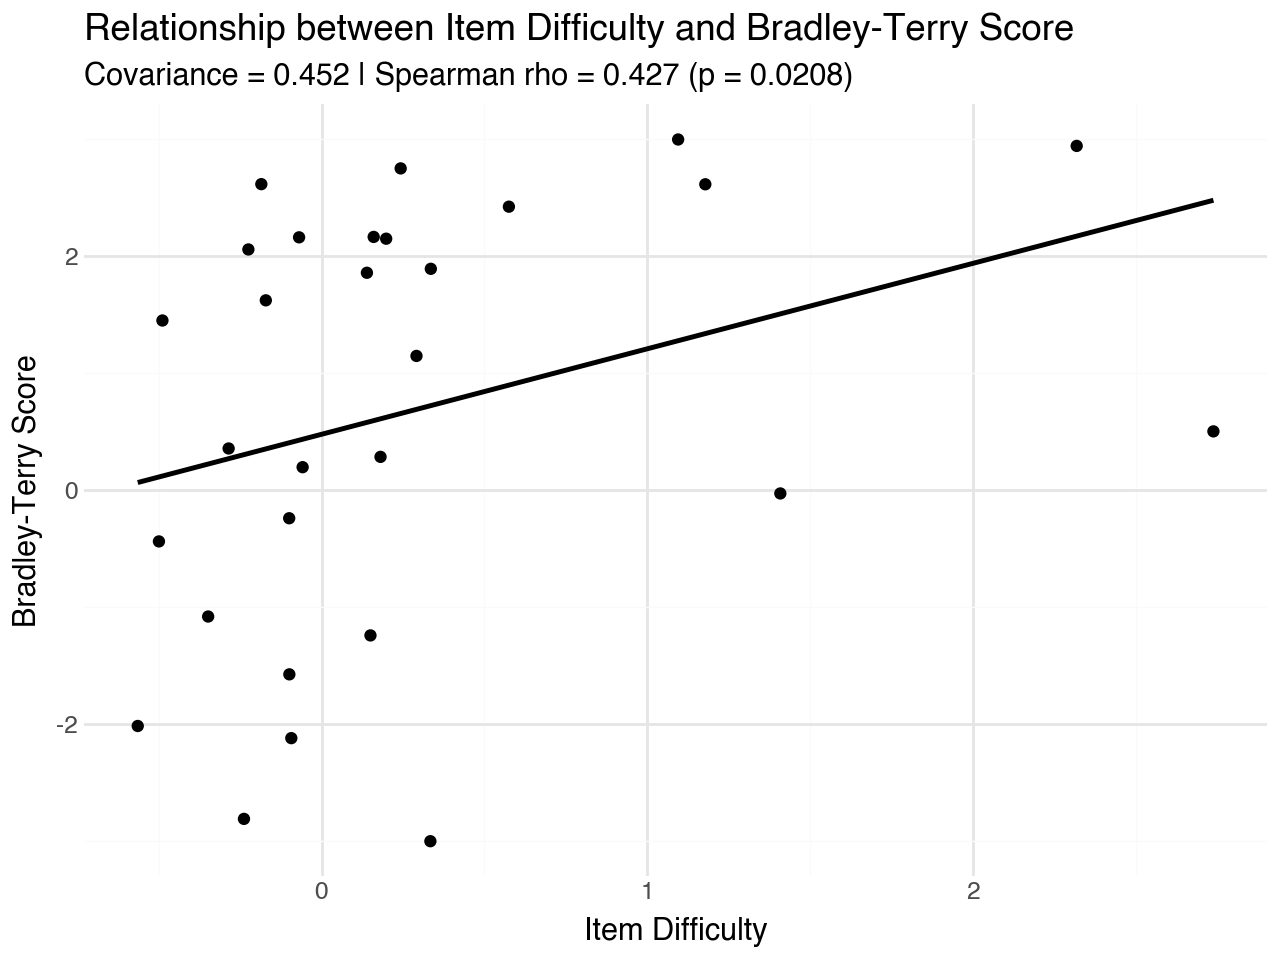

In [101]:
from scipy.stats import spearmanr
from plotnine import ggplot, aes, geom_point, geom_smooth, theme_minimal, labs

# Keep only non-missing values for both variables
plot_df = all_item_scores[['b', 'Bradley_Terry_Score']].dropna()

# Compute metrics
covariance = plot_df['b'].cov(plot_df['Bradley_Terry_Score'])
spearman_rho, spearman_p = spearmanr(plot_df['b'], plot_df['Bradley_Terry_Score'])

subtitle_txt = (
    f"Covariance = {covariance:.3f} | "
    f"Spearman rho = {spearman_rho:.3f} (p = {spearman_p:.3g})"
)

(
    ggplot(plot_df, aes(x='b', y='Bradley_Terry_Score'))
    + geom_point()
    + geom_smooth(method='lm', se=False)
    + theme_minimal()
    + labs(
        title='Relationship between Item Difficulty and Bradley-Terry Score',
        subtitle=subtitle_txt,
        x='Item Difficulty',
        y='Bradley-Terry Score'
    )
)